In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('../datasets/cleaned_crop.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (2200, 9)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'crop_encoded']


,N,P,K,temperature,humidity,ph,rainfall,label,crop_encoded
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,20


In [3]:
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['crop_encoded']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Total crop classes:", y.nunique())

Features shape: (2200, 7)
Target shape: (2200,)
Total crop classes: 22


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1760
Testing samples: 440


In [5]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

results = {}

print("Training models...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"✅ {name}: {acc*100:.2f}%")

Training models...

✅ Random Forest: 99.55%
✅ XGBoost: 99.09%
✅ Gradient Boosting: 98.86%
✅ Logistic Regression: 94.55%


c:\Users\Athisk K\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


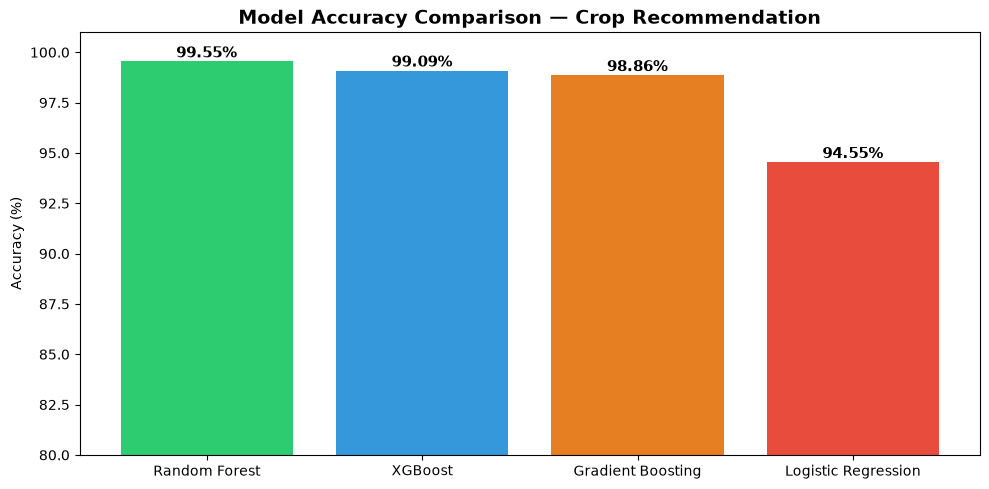

Chart saved!


In [6]:
plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
bars = plt.bar(results.keys(), [v*100 for v in results.values()], color=colors)
plt.title('Model Accuracy Comparison — Crop Recommendation', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(80, 101)
for bar, (k, v) in zip(bars, results.items()):
    plt.text(bar.get_x() + bar.get_width()/2,
             v*100 + 0.2,
             f"{v*100:.2f}%",
             ha='center',
             fontweight='bold',
             fontsize=11)
plt.tight_layout()
plt.savefig('../models/crop_model_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

In [7]:
best_name = max(results, key=results.get)
best_model = models[best_name]

print(f"🏆 Best Model: {best_name}")
print(f"🎯 Accuracy: {results[best_name]*100:.2f}%\n")

y_pred_best = best_model.predict(X_test)
le_crop = pickle.load(open('../models/crop_encoder.pkl', 'rb'))

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=le_crop.classes_
))

🏆 Best Model: Random Forest
🎯 Accuracy: 99.55%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      oran

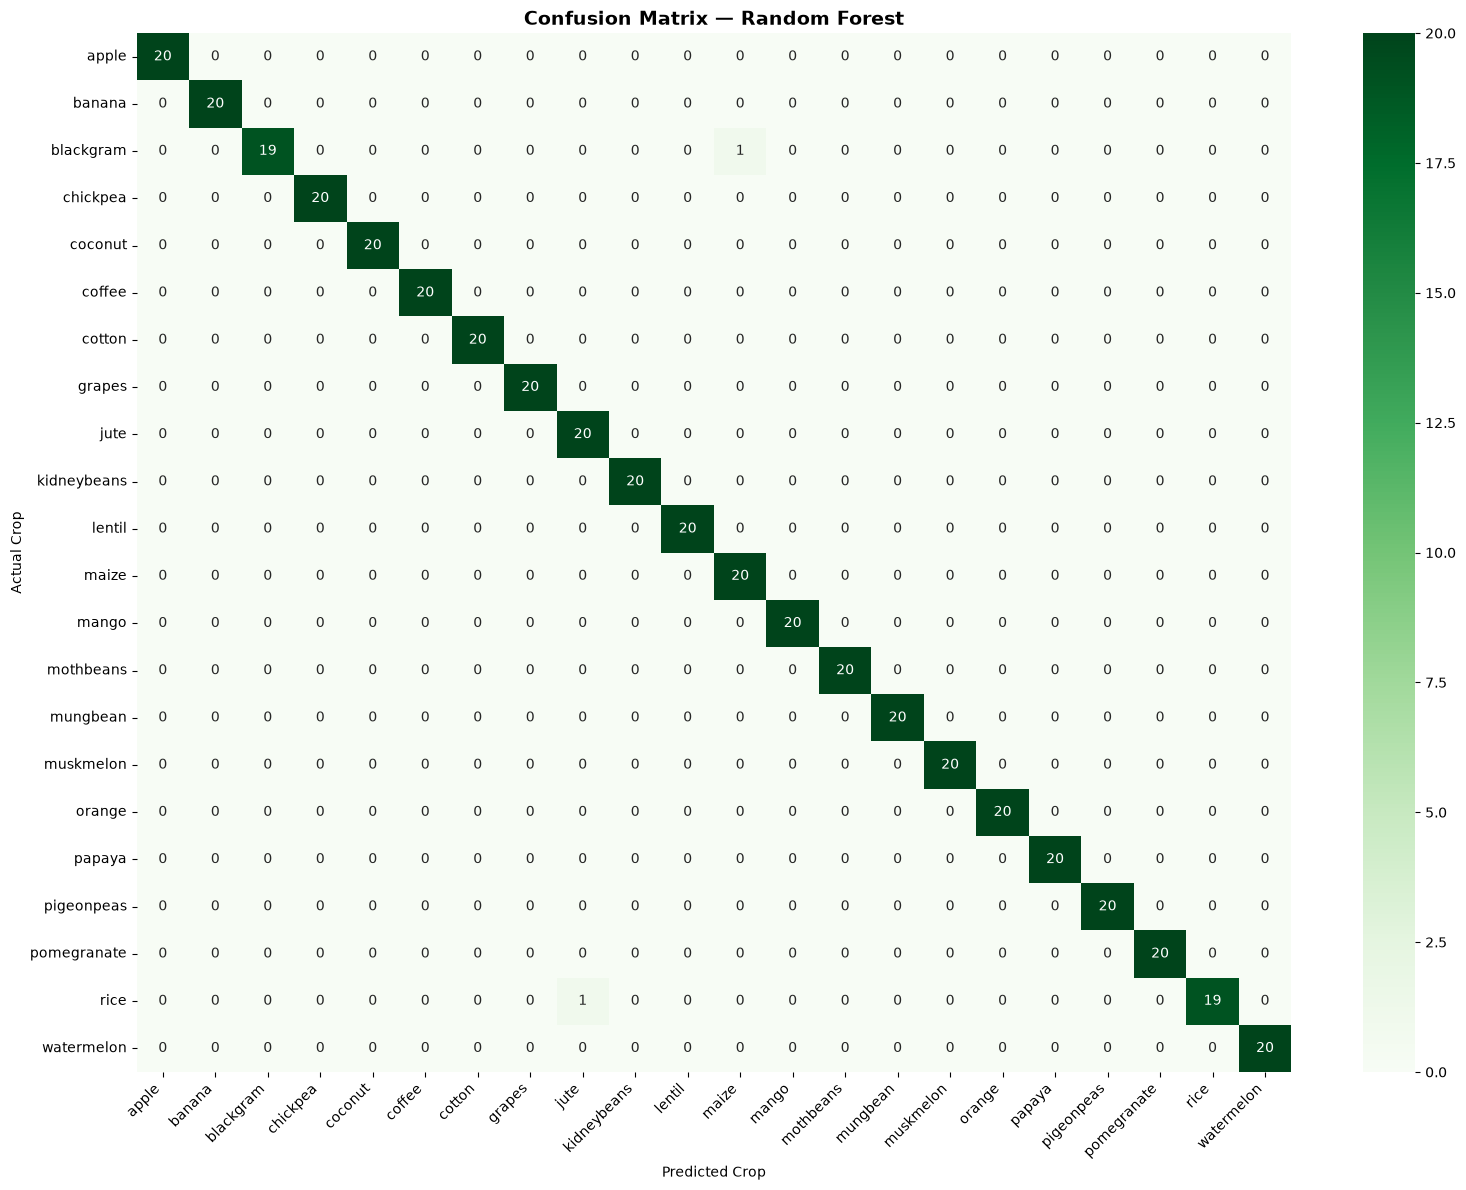

Confusion matrix saved!


In [8]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(16, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=le_crop.classes_,
            yticklabels=le_crop.classes_)
plt.title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual Crop')
plt.xlabel('Predicted Crop')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../models/crop_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

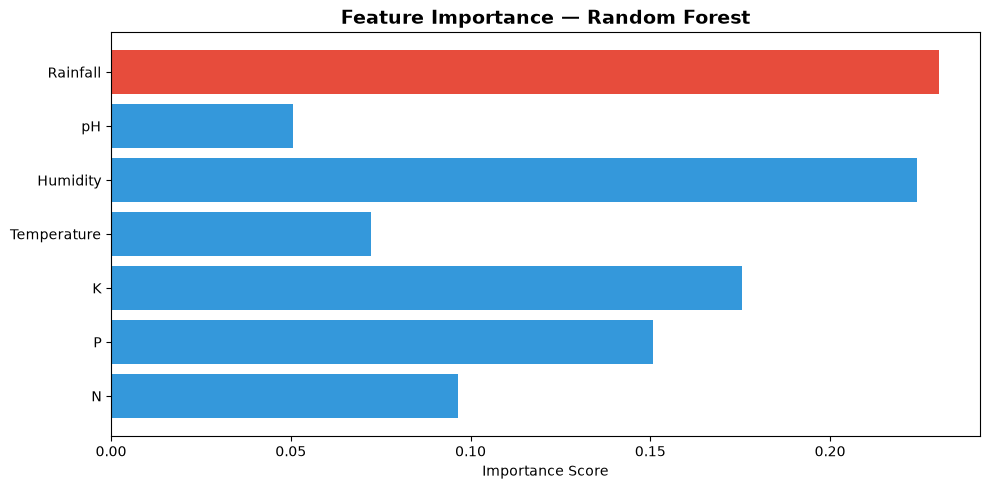

Feature importance chart saved!


In [9]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = ['N', 'P', 'K', 'Temperature', 'Humidity', 'pH', 'Rainfall']

    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if x == max(importances) else '#3498db' for x in importances]
    plt.barh(feature_names, importances, color=colors)
    plt.title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../models/crop_feature_importance.png', dpi=150)
    plt.show()
    print("Feature importance chart saved!")

In [10]:
sample = pd.DataFrame([[90, 42, 43, 20.87, 82.00, 6.50, 202.93]],
                      columns=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'])

proba = best_model.predict_proba(sample)[0]
top5_idx = np.argsort(proba)[::-1][:5]
top5_crops = le_crop.classes_[top5_idx]
top5_conf = proba[top5_idx] * 100

print("🌾 Top 5 Crop Recommendations:")
print("-" * 35)
for i, (crop, conf) in enumerate(zip(top5_crops, top5_conf)):
    bar = "█" * int(conf // 5)
    print(f"  {i+1}. {crop.title():<15} {conf:.2f}% {bar}")

🌾 Top 5 Crop Recommendations:
-----------------------------------
  1. Rice            90.00% ██████████████████
  2. Jute            10.00% ██
  3. Pomegranate     0.00% 
  4. Pigeonpeas      0.00% 
  5. Papaya          0.00% 


In [11]:
pickle.dump(best_model, open('../models/crop_model.pkl', 'wb'))
print(f"✅ Best model saved: crop_model.pkl")
print(f"   Algorithm: {best_name}")
print(f"   Accuracy: {results[best_name]*100:.2f}%")

✅ Best model saved: crop_model.pkl
   Algorithm: Random Forest
   Accuracy: 99.55%


In [12]:
import json

metadata = {
    'best_model': best_name,
    'accuracy': round(results[best_name] * 100, 2),
    'all_results': {k: round(v*100, 2) for k, v in results.items()},
    'features': ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'],
    'total_classes': int(y.nunique())
}

with open('../models/crop_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("✅ Metadata saved: crop_model_metadata.json")
print(json.dumps(metadata, indent=4))

✅ Metadata saved: crop_model_metadata.json
{
    "best_model": "Random Forest",
    "accuracy": 99.55,
    "all_results": {
        "Random Forest": 99.55,
        "XGBoost": 99.09,
        "Gradient Boosting": 98.86,
        "Logistic Regression": 94.55
    },
    "features": [
        "N",
        "P",
        "K",
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ],
    "total_classes": 22
}


In [13]:
print("=" * 40)
print("   PHASE 3 — CROP MODEL COMPLETE")
print("=" * 40)

loaded = pickle.load(open('../models/crop_model.pkl', 'rb'))
proba = loaded.predict_proba(sample)[0]
top5_idx = np.argsort(proba)[::-1][:5]

print(f"\n✅ Model loads correctly")
print(f"✅ Algorithm: {best_name}")
print(f"✅ Accuracy: {results[best_name]*100:.2f}%")
print(f"✅ Top prediction: {le_crop.classes_[top5_idx[0]].title()}")
print("\nFiles saved in models/:")
print("  - crop_model.pkl")
print("  - crop_encoder.pkl")
print("  - crop_model_comparison.png")
print("  - crop_confusion_matrix.png")
print("  - crop_feature_importance.png")
print("  - crop_model_metadata.json")

   PHASE 3 — CROP MODEL COMPLETE

✅ Model loads correctly
✅ Algorithm: Random Forest
✅ Accuracy: 99.55%
✅ Top prediction: Rice

Files saved in models/:
  - crop_model.pkl
  - crop_encoder.pkl
  - crop_model_comparison.png
  - crop_confusion_matrix.png
  - crop_feature_importance.png
  - crop_model_metadata.json
